# ETFs Deployment Loop

**Docker image**: `ml4t`

**Book Reference**: Chapter 25, Section 25.7 (Operational readiness)

This notebook is the chapter's anchor demonstration of the end-to-end
deployment cycle. Where the rest of the book trains, evaluates, and
backtests against the frozen 2025-12-31 cut, this notebook is the one
place where the data extends past that cut: a live deployment must
refresh its inputs, refit the model on the extended history, predict
the latest scheduled cross-section, and stage paper-broker orders. The cycle has
seven steps:

1. **Refresh** ETF bars to the most recent available date through
   `ml4t-data`'s `ETFDataManager.update()`.
2. **Recompute** financial features on the extended panel.
3. **Retrain** a Ridge regressor with the regularisation strength the
   case study identified, using the financial-only feature subset.
4. **Persist** the deployment artefacts under
   `25_live_trading/output/etfs_deployment/`.
5. **Predict** the live window's cross-sections.
6. **Replay** the live window through `ml4t.backtest.Engine` to produce
   the offline reference signal tape - the trade record a deterministic
   historical replay would have generated.
7. **Stage** the latest scheduled top-K basket for an explicitly armed
   Alpaca paper session, then persist a run JSON capturing the
   cross-section, the offline tape, and the per-symbol execution
   disposition.

**Important framing.** This notebook is a deployment-engineering
rehearsal, not investment advice. When Alpaca paper credentials are
present, refreshed inputs are current, and the explicit opt-in is enabled,
the notebook can route the scheduled basket through an Alpaca paper session.
The default execution plane is an offline dry run against the reference tape.

**Cross-References**
- Chapter 6: Strategy research for ETFs (case study setup)
- Chapter 8: Financial feature engineering
- Chapter 11: Linear models on tabular features
- Chapter 25.3: Integrating with Alpaca
- Chapter 25.6: Ensuring technical parity through pipeline verification
- Chapter 26: Repeated model serving and monitoring

**Learning Objectives**
- Run a full retrain-and-deploy cycle on real ETF data with no mock
  components.
- Persist deployment artefacts separately from research registry runs.
- Stage a basket for Alpaca paper equities and reconcile the intended
  basket against the offline reference signal tape produced
  by `ml4t.backtest.Engine`.

**Prerequisites**
- ETF data downloaded under `ML4T_DATA_PATH/etfs/market`.
- FRED macro data under `ML4T_DATA_PATH/macro` (for the yield-curve
  regime feature).
- The ETFs case study's forward-return label parquet and its registry,
  by default `case_studies/etfs/labels/fwd_ret_21d.parquet` and
  `case_studies/etfs/run_log/registry.db`.
- Alpaca paper credentials in `ALPACA_API_KEY` / `ALPACA_SECRET_KEY`
  (free at <https://app.alpaca.markets/paper>).

In [1]:
"""Refresh, refit, predict, stage a paper basket, and persist its audit record."""

import json
import logging
import os
import pickle
import sqlite3
import warnings
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from _etfs_features import build_yield_curve, compute_financial_features, feature_columns
from async_utils import run_async
from ml4t.backtest import (
    BacktestConfig,
    DataFeed,
    Engine,
    ExecutionMode,
    OrderSide,
    OrderStatus,
    Strategy,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

from data import load_etfs, load_macro
from utils.paths import display_path, get_case_study_dir, get_output_dir
from utils.style import COLORS, add_message_title, show_with_alt

# basicConfig is a no-op once a handler exists, and importing the feature libraries installs one,
# so configuring the root logger here would leave two handlers attached and print every line
# twice. Give this notebook its own logger and its own handler instead, and leave the root alone.
logger = logging.getLogger("etfs_deployment")
logger.setLevel(logging.INFO)
logger.propagate = False
if not logger.handlers:
    _handler = logging.StreamHandler()
    _handler.setFormatter(logging.Formatter("%(asctime)s %(levelname)s %(message)s"))
    logger.addHandler(_handler)
for _noisy in ("ml4t", "mlquant", "mlquant.features"):
    logging.getLogger(_noisy).setLevel(logging.WARNING)

In [2]:
EXPECTED_RIDGE_CONFIG = "ridge_a1000000.0"  # None reports the registry's pick instead of asserting
PRIMARY_LABEL = "fwd_ret_21d"
LIVE_WINDOW_START = "2025-01-01"  # cross-sections from here become "live" predictions
FORWARD_HORIZON_DAYS = 21  # fwd_ret_21d label horizon (trading days)
TOP_K = 5
CASH_BUFFER = 0.02  # share of the account left unallocated, so a next-bar fill is affordable
REBALANCE_EVERY_N_DAYS = 21  # match the label horizon
INITIAL_CASH = 100_000.0
COMMISSION_RATE = 0.0005
NOTIONAL_PER_LEG_USD = 5_000.0  # per-leg paper notional for the live submission
SUBMIT_PAPER_ORDERS = False  # explicit opt-in; the default is an offline dry run
REFRESH_DATA = False  # if True, call ml4t-data update to pull bars past 2025-12-31

## 1. Refresh Data

The deployment loop's first step is bringing the local ETF panel up to
date. `ml4t.data.etfs.ETFDataManager.update()` reads the existing
Hive-partitioned parquets, detects the last date per symbol, and pulls
only the missing tail from Yahoo. The book ships data through
2025-12-31; this notebook is the only place that knowingly reaches
beyond that cut.

When `REFRESH_DATA=False` the step is skipped and the existing panel is
used as-is, which makes the rest of the notebook reproducible against
the frozen book data.

In [3]:
if REFRESH_DATA:
    from datetime import date

    from ml4t.data.etfs import ETFDataManager

    config_path = Path("data/etfs/market/config.yaml")
    manager = ETFDataManager.from_config(config_path)
    manager.config.storage_path = Path(os.environ["ML4T_DATA_PATH"]) / "etfs" / "market"
    manager.config.end = date.today().isoformat()
    update_stats = manager.update()
    manager._regenerate_combined()
    new_rows = sum(update_stats.values())
    print(
        f"ml4t-data update: {new_rows:,} new rows across {sum(1 for v in update_stats.values() if v)} symbols"
    )
else:
    print("Data refresh skipped (REFRESH_DATA=False); using existing 2025-12-31 panel")

Data refresh skipped (REFRESH_DATA=False); using existing 2025-12-31 panel


## 2. Load Inputs and Compute Features

The financial-only feature pipeline lives in `_etfs_features.py` next to
this notebook - it sequences the same `compute_*` functions the case
study uses, drops the model-based path (HMM regimes, GARCH), and
returns a single panel ready for training. The model-based features
would inflate feature count by ~10 columns at the cost of an HMM and a
GARCH refit per symbol on every retrain; the deployment trade is to
accept a slightly weaker feature set in exchange for a refit that
completes in seconds rather than minutes.

In [4]:
prices = (
    load_etfs()
    .select(["symbol", "timestamp", "open", "high", "low", "close", "volume"])
    .sort(["symbol", "timestamp"])
)
print(
    f"Prices: {len(prices):,} rows x {prices['symbol'].n_unique()} symbols, "
    f"{prices['timestamp'].min()} to {prices['timestamp'].max()}"
)

yield_curve = build_yield_curve(load_macro())
print(f"Yield-curve frame: {len(yield_curve):,} rows")

Prices: 470,662 rows x 100 symbols, 2006-01-03 to 2025-12-31
Yield-curve frame: 9,495 rows


In [5]:
features = compute_financial_features(prices, yield_curve)
fc = feature_columns(features)
print(f"Features: {features.shape}, {len(fc)} feature columns")

2026-09-10 20:38:51 | mlquant.features.adx | INFO | [ADX] Starting calculation with parameters: period=14 (shape: (4,))


2026-09-10 20:38:51 | mlquant.features.adx | INFO | [ADX] Completed calculation (shape: (4,)) (0.05ms)


Features: (470662, 65), 57 feature columns


## 3. Build Training Matrix and Refit

Training joins features against the case study's `fwd_ret_21d` label
parquet on `(timestamp, symbol)`. The label horizon is 21 trading days,
so the latest training row sits 21 days before the most recent feature
row. Anything in the live window has features but no label and is
reserved for prediction only.

The deployment fit is a **single Ridge regression on the full extended
panel** - no walk-forward CV, no per-fold scaling, no hyperparameter
search. The regularisation strength comes from the case study rather
than from a sweep here, which separates the *research artefact*
(registry-stored, CV-evaluated, IC-reported) from the *deployment
artefact* (single fit, full history, governed path).

### Where the regularisation strength comes from

A borrowed hyperparameter that sits in the parameters cell as a literal is a number nobody can
check: the registry's leader can move on the next sweep and nothing here would notice. The cell
below asks the registry which Ridge configuration leads on validation IC for this label, reads
the alpha out of that run's resolved specification, and checks the answer against
`EXPECTED_RIDGE_CONFIG`. Setting that pin to `None` reports the registry's pick instead of
asserting it, which is what to do when the case study is deliberately re-swept.

The pin names a **configuration**, not a training hash. A refit re-keys the hash while selecting
the same configuration, so a hash pin would fire on runs where nothing had changed.

In [6]:
etfs_dir = get_case_study_dir("etfs")
labels_path = etfs_dir / "labels" / f"{PRIMARY_LABEL}.parquet"
registry_path = etfs_dir / "run_log" / "registry.db"
# Read-only, but not `immutable=1`: the registry is a WAL database that sweeps write to
# concurrently, and an immutable connection ignores the -wal file and reads the pre-WAL main
# file, which shows up here as a stale leader or as a table that appears not to exist.
registry_uri = f"{registry_path.resolve().as_uri()}?mode=ro"
with sqlite3.connect(registry_uri, uri=True) as conn:
    winner = conn.execute(
        """SELECT tr.config_name, tr.spec_json, pm.ic_mean
           FROM training_runs tr
           JOIN prediction_sets ps ON ps.training_hash = tr.training_hash
           JOIN prediction_metrics pm ON pm.prediction_hash = ps.prediction_hash
           WHERE tr.family = 'linear'
             AND tr.label = ?
             AND tr.config_name LIKE 'ridge_%'
             AND ps.split = 'validation'
           ORDER BY pm.ic_mean DESC
           LIMIT 1""",
        (PRIMARY_LABEL,),
    ).fetchone()
if winner is None:
    raise RuntimeError(
        f"The ETFs registry holds no validated Ridge run for {PRIMARY_LABEL}; "
        "the case study's linear stage has to run before this notebook can borrow from it."
    )
SOURCE_CONFIG, source_spec_json, source_ic = winner
source_spec = json.loads(source_spec_json)

# Every fold of a sweep configuration is fitted at one alpha; a set with more than one member
# would mean the configuration name no longer identifies a single regularisation strength.
fold_alphas = {
    params["alpha"]
    for params in source_spec["computation"]["model"]["effective_params_by_fold"].values()
}
if len(fold_alphas) != 1:
    raise RuntimeError(f"{SOURCE_CONFIG} was fitted at more than one alpha: {sorted(fold_alphas)}")
RIDGE_ALPHA = float(fold_alphas.pop())

# The artefacts the source run read are what its feature set was; "label" is the target, not a
# feature family.
SOURCE_FEATURE_SETS = sorted(set(source_spec["computation"]["feature_artifacts"]) - {"label"})

# `_etfs_features.compute_financial_features` builds exactly the financial families, so this names
# what was fitted above rather than restating an intention.
DEPLOYED_FEATURE_SETS = ["financial"]

assert EXPECTED_RIDGE_CONFIG in (None, SOURCE_CONFIG), (
    f"The registry now leads with {SOURCE_CONFIG}, not {EXPECTED_RIDGE_CONFIG}. "
    "Re-pin deliberately rather than following the leader silently."
)
print(f"Registry leader on validation IC: {SOURCE_CONFIG}  (IC {source_ic:.4f})")
print(f"  alpha:        {RIDGE_ALPHA:g}")
print(f"  tuned on:     {SOURCE_FEATURE_SETS}")
print(f"  deployed on:  {DEPLOYED_FEATURE_SETS}")

Registry leader on validation IC: ridge_a1000000.0  (IC 0.0434)
  alpha:        1e+06
  tuned on:     ['financial', 'model_based']
  deployed on:  ['financial']


The two feature lists differ, and the difference is the cost of the transfer. The registry's
leader was tuned with the model-based families alongside the financial ones; this notebook fits
the financial families alone, because an HMM and a GARCH refit per symbol on every data update is
what the deployment declines to pay for. An alpha selected against one feature set is not
selected against another, so the number below is a starting point carried over from research,
not a tuned value for the model actually fitted here. Nothing in this notebook re-derives it, and
a deployment that wanted it re-derived would sweep on its own feature set.

In [7]:
labels = pl.read_parquet(labels_path)
panel = features.join(labels, on=["timestamp", "symbol"], how="inner")
print(f"Joined panel: {len(panel):,} rows over {panel['symbol'].n_unique()} symbols")

Joined panel: 468,562 rows over 100 symbols


### Lookahead Guard

`fwd_ret_21d` at timestamp `t` reads the price `t + 21 trading days` into the future. If training cuts at
`t = LIVE_WINDOW_START - 1 day`, the labels for the final 21 trading days of training were computed from
prices that are themselves inside the live window - the prices we are about to predict against. To
keep training strictly upstream of the live window, the train mask cuts at `LABEL_AVAILABLE_AS_OF`, which
is the last trading day whose forward-horizon label realizes before `LIVE_WINDOW_START`.

In [8]:
trading_days = panel.select("timestamp").unique().sort("timestamp")["timestamp"].to_list()
live_start_date = pl.Series([LIVE_WINDOW_START]).str.to_date()[0]
days_before_live = [d for d in trading_days if d < live_start_date]
if len(days_before_live) <= FORWARD_HORIZON_DAYS:
    raise ValueError(
        f"Panel has only {len(days_before_live)} trading days before LIVE_WINDOW_START "
        f"({LIVE_WINDOW_START}); cannot guarantee {FORWARD_HORIZON_DAYS}-day horizon margin."
    )
LABEL_AVAILABLE_AS_OF = days_before_live[-FORWARD_HORIZON_DAYS - 1]
FEATURE_CUTOFF_DATE = days_before_live[-1]
print(
    f"Feature cutoff:        {FEATURE_CUTOFF_DATE}\n"
    f"Label available as of: {LABEL_AVAILABLE_AS_OF}  "
    f"({FORWARD_HORIZON_DAYS} trading days before {LIVE_WINDOW_START})"
)

Feature cutoff:        2024-12-31
Label available as of: 2024-11-29  (21 trading days before 2025-01-01)


In [9]:
train_mask = pl.col("timestamp") <= pl.lit(LABEL_AVAILABLE_AS_OF)
training = panel.filter(train_mask).drop_nulls(subset=[PRIMARY_LABEL])
assert training["timestamp"].max() <= LABEL_AVAILABLE_AS_OF
X_train = training.select(fc).to_numpy()
y_train = training[PRIMARY_LABEL].to_numpy()

imputer = SimpleImputer(strategy="median").fit(X_train)
scaler = StandardScaler().fit(imputer.transform(X_train))
model = Ridge(alpha=RIDGE_ALPHA).fit(scaler.transform(imputer.transform(X_train)), y_train)

print(f"Training rows: {len(X_train):,} | features: {len(fc)} | α = {RIDGE_ALPHA:g}")
print(f"Coefficient L2 norm: {np.linalg.norm(model.coef_):.4f}  intercept: {model.intercept_:.6f}")

Training rows: 443,562 | features: 57 | α = 1e+06
Coefficient L2 norm: 0.0025  intercept: 0.006148


## 4. Persist the Deployment Artefact

The artefact is written to a chapter-local path so it cannot drift into
the case-study research registry. Each run records the data range used,
the training timestamp, the source case-study configuration, and the
feature column order. The column order is part of the contract because
the predict step depends on column-positional alignment.

In [10]:
ARTIFACT_DIR = get_output_dir(25, "etfs_deployment")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
RUNS_DIR = ARTIFACT_DIR / "runs"
RUNS_DIR.mkdir(exist_ok=True)

with open(ARTIFACT_DIR / "model.pkl", "wb") as f:
    pickle.dump(model, f)
with open(ARTIFACT_DIR / "imputer.pkl", "wb") as f:
    pickle.dump(imputer, f)
with open(ARTIFACT_DIR / "scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
with open(ARTIFACT_DIR / "feature_columns.json", "w") as f:
    json.dump(fc, f, indent=2)

training_metadata = {
    "trained_at": datetime.now(UTC).isoformat(),
    "data_range": {
        "start": str(training["timestamp"].min()),
        "end": str(training["timestamp"].max()),
    },
    "feature_cutoff_date": str(FEATURE_CUTOFF_DATE),
    "label_available_as_of": str(LABEL_AVAILABLE_AS_OF),
    "forward_horizon_days": FORWARD_HORIZON_DAYS,
    "live_window_start": LIVE_WINDOW_START,
    "n_train_rows": int(len(X_train)),
    "n_features": len(fc),
    "label": PRIMARY_LABEL,
    "model_class": "sklearn.linear_model.Ridge",
    "ridge_alpha": RIDGE_ALPHA,
    "source_case_study": "etfs",
    "source_config_name": SOURCE_CONFIG,
    "source_config_feature_sets": SOURCE_FEATURE_SETS,  # what the alpha was tuned on
    "deployed_feature_sets": DEPLOYED_FEATURE_SETS,  # what this fit used
    "intercept": float(model.intercept_),
    "coef_l2_norm": float(np.linalg.norm(model.coef_)),
}
with open(ARTIFACT_DIR / "training_metadata.json", "w") as f:
    json.dump(training_metadata, f, indent=2)

print(f"Artefact written to {display_path(ARTIFACT_DIR)}")

Artefact written to 25_live_trading/output/etfs_deployment


## 5. Predict the Live Window

Predictions cover every cross-section from `LIVE_WINDOW_START` onward.
Rows with all-null features are dropped; remaining nulls flow through
the persisted imputer. The same prediction tape feeds both downstream
paths - the offline `Engine` replay (§7) and the staged Alpaca paper
submission (§8) - so any divergence in their behaviour traces back to
fill-timing or broker-side details rather than model output.

In [11]:
live_mask = pl.col("timestamp") >= pl.lit(LIVE_WINDOW_START).str.to_date()
# Drop only rows whose entire feature row is null (no signal); rows with a
# few warmup-incomplete columns flow through the persisted SimpleImputer
# (median fill), matching the training pipeline above.
live_panel = features.filter(live_mask).select(["timestamp", "symbol", *fc])
live_panel = live_panel.filter(~pl.all_horizontal([pl.col(c).is_null() for c in fc]))
X_live = live_panel.select(fc).to_numpy()
preds = model.predict(scaler.transform(imputer.transform(X_live)))
predictions = live_panel.select(["timestamp", "symbol"]).with_columns(pl.Series("score", preds))
# The live window must reach the end of the feature panel: a prediction tape that stops short is
# how a deployment silently scores a stale cross-section. Comparing against `predictions` itself
# would compare the frame with a copy of its own column and could not fail.
assert predictions["timestamp"].max() == features["timestamp"].max(), (
    f"Predictions stop at {predictions['timestamp'].max()} but features run to "
    f"{features['timestamp'].max()}; the newest cross-section carries no score."
)
print(
    f"Predictions over live window: {len(predictions):,} rows on {predictions['timestamp'].n_unique()} dates"
)

Predictions over live window: 25,000 rows on 250 dates


## 6. Build the Cross-Sectional Strategy

The deployment strategy holds the top-`TOP_K` predicted ETFs equal-
weighted, rebalancing every `REBALANCE_EVERY_N_DAYS` trading days. The
`on_data` interface is identical to every other strategy in this
chapter: receive the bar dictionary, look up the prediction frame for
the current timestamp, compute target weights, route orders.

Positions are sized against the broker's current account value rather than `INITIAL_CASH`, so
leverage stays constant as profit and loss accrue, and against slightly less than all of it.
`CASH_BUFFER` is what the order is sized on the current bar's close but fills at the next bar's:
an overnight move against the position, plus commission, makes a basket sized at the full account
value unaffordable, and the broker answers that by refusing the last leg rather than by filling
it smaller. Two per cent is a margin measured on this window, not a guarantee - a basket that
gaps up about two per cent overnight is unaffordable again - and the disposition check below is
what turns that into a stop rather than a quietly short basket.

In [12]:
# compliance: skip cell_size - one Strategy binds predictions, broker, and the signal log
class CrossSectionalRidgeStrategy(Strategy):
    """Top-K equal-weight basket from the persisted Ridge predictions."""

    def __init__(
        self,
        predictions: pl.DataFrame,
        top_k: int,
        rebalance_every: int,
        symbols: list[str],
        cash_buffer: float,
    ):
        self.predictions = predictions
        self.top_k = top_k
        self.rebalance_every = rebalance_every
        self.symbols = symbols
        self.cash_buffer = cash_buffer
        self._bars_seen = 0
        self.signal_log: list[dict] = []
        self.rebalance_log: list[dict] = []

    def on_start(self, broker):
        self._bars_seen = 0
        self.signal_log = []
        self.rebalance_log = []

    def on_data(self, timestamp, data, context, broker):
        self._bars_seen += 1
        if (self._bars_seen - 1) % self.rebalance_every != 0:
            return

        ts = timestamp.date() if hasattr(timestamp, "date") else timestamp
        ts = pl.lit(ts).cast(pl.Date)
        scores = self.predictions.filter(pl.col("timestamp") == ts).sort("score", descending=True)
        if len(scores) == 0:
            return

        targets = scores.head(self.top_k)["symbol"].to_list()
        target_set = set(targets)
        self.rebalance_log.append({"timestamp": timestamp, "targets": targets})
        prices = {s: data[s]["close"] for s in self.symbols if s in data}

        account_value = broker.get_account_value() * (1.0 - self.cash_buffer)

        for symbol in self.symbols:
            position = broker.get_position(symbol)
            qty = float(position.quantity) if position is not None else 0.0

            if symbol in target_set:
                # Held symbol with no bar this period: hold through the gap
                # rather than treating absence as an exit signal.
                if symbol not in prices:
                    continue
                weight = 1.0 / self.top_k
                cash_value = account_value * weight
                target_qty = round(cash_value / prices[symbol])
            else:
                target_qty = 0.0

            delta = target_qty - qty
            if abs(delta) < 1:
                continue

            side = OrderSide.BUY if delta > 0 else OrderSide.SELL
            broker.submit_order(symbol, abs(int(delta)), side=side)
            self.signal_log.append(
                {
                    "timestamp": timestamp,
                    "symbol": symbol,
                    "side": side.value,
                    "delta": int(delta),
                    "target_qty": int(target_qty),
                    "score": float(scores.filter(pl.col("symbol") == symbol)["score"][0])
                    if symbol in target_set
                    else None,
                }
            )

    def on_end(self, broker):
        pass

## 7. Offline Reference Tape through `ml4t.backtest.Engine`

Replaying the live window through `ml4t.backtest.Engine` with
`NEXT_BAR` execution produces the offline reference signal tape: every
rebalance the deployment would have made if the loop had run live each
day from `LIVE_WINDOW_START` through the latest available date. This
tape is the deterministic counterfactual the §9 reconciliation
compares against. The question is not "did the live broker fill at
the same price as the backtest" (it cannot because fills happen at live
market prices) but "did the live broker receive the same basket on
the latest rebalance date as the offline replay produced."

In [13]:
live_prices = prices.filter(pl.col("timestamp") >= pl.lit(LIVE_WINDOW_START).str.to_date())
backtest_input = live_prices
ALL_SYMBOLS = sorted(predictions["symbol"].unique().to_list())

feed_backtest = DataFeed(prices_df=backtest_input)
strategy_backtest = CrossSectionalRidgeStrategy(
    predictions=predictions,
    top_k=TOP_K,
    rebalance_every=REBALANCE_EVERY_N_DAYS,
    symbols=ALL_SYMBOLS,
    cash_buffer=CASH_BUFFER,
)
engine_backtest = Engine(
    feed=feed_backtest,
    strategy=strategy_backtest,
    config=BacktestConfig(
        initial_cash=INITIAL_CASH,
        execution_mode=ExecutionMode.NEXT_BAR,
        commission_rate=COMMISSION_RATE,
    ),
)
backtest_results = engine_backtest.run()
assert strategy_backtest.rebalance_log, "Offline replay produced no scheduled rebalances"
print(f"Backtest final value: ${backtest_results['final_value']:,.2f}")
print(f"Backtest total return: {backtest_results['total_return_pct']:.2f}%")
print(f"Backtest signals: {len(strategy_backtest.signal_log)}")

Backtest final value: $145,736.79
Backtest total return: 45.74%
Backtest signals: 84


The replay is read below as the deterministic record of what the deployment would have done, so
an order it emitted and the broker refused has to stop it being read that way. The same four
buckets the live leg reports apply here: a signal the strategy logged is intended, and only a
filled order is accepted. Sizing every leg at the full account value produced eight refusals
over this window before `CASH_BUFFER` existed, and nothing in the notebook looked.

An order still pending on the last bar is a different thing and is counted separately. Under
`NEXT_BAR` the engine fills an order at the start of the following bar, and the final bar has
no following bar, so a rebalance that lands on the last day of the window leaves its whole
basket unfilled. That is the replay running out of tape, not the broker refusing anything.

In [14]:
last_bar_ts = engine_backtest.equity_curve[-1][0]
refused, pending_at_end = [], []
for order in engine_backtest.broker.orders:
    if order.status is OrderStatus.FILLED:
        continue
    if order.status is OrderStatus.PENDING and order.created_at == last_bar_ts:
        pending_at_end.append(order)
    else:
        refused.append(order)

print(f"Offline orders: {len(engine_backtest.broker.orders)}")
print(f"  filled:              {len(engine_backtest.broker.fills)}")
print(f"  unfilled at the end: {len(pending_at_end)}")
print(f"  refused:             {len(refused)}")
for order in refused[:5]:
    print(f"    {order.asset} {order.side.value} {order.quantity:g}: {order.rejection_reason}")
assert not refused, (
    f"The offline replay did not place the basket it logged: {len(refused)} order(s) refused. "
    "A refused order means the reference tape and the strategy's own signal log disagree, "
    "so the reconciliation below would compare an intended basket against one never held."
)

Offline orders: 84
  filled:              84
  unfilled at the end: 0
  refused:             0


### What the replay looks like over the window

The return above is one number for a year, and it hides the two things a deployment review asks
first: whether the strategy made its money steadily or in one stretch, and how deep it went
underwater on the way. A single figure answers both, and neither is available from the summary.

This is the offline reference tape, not a live result. It is what a deterministic replay of the
live window would have produced, and it exists to be reconciled against the basket actually
staged below.

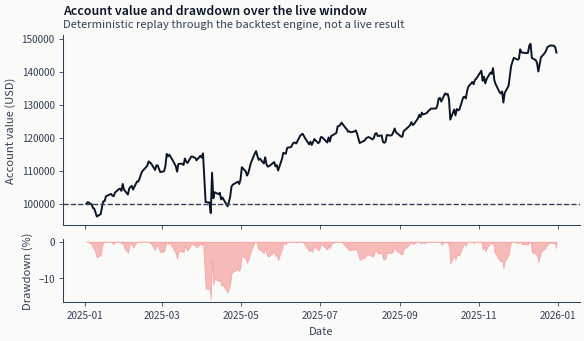

In [15]:
equity_dates = [ts for ts, _ in engine_backtest.equity_curve]
equity_values = np.asarray([value for _, value in engine_backtest.equity_curve], dtype=float)
drawdown = equity_values / np.maximum.accumulate(equity_values) - 1.0

fig, axes = plt.subplots(2, 1, sharex=True, height_ratios=[3, 1])
axes[0].plot(equity_dates, equity_values, color=COLORS["blue"], linewidth=1.4)
axes[0].axhline(INITIAL_CASH, color=COLORS["neutral"], linestyle="--", linewidth=1)
axes[0].set_ylabel("Account value (USD)")
axes[1].fill_between(equity_dates, drawdown * 100, 0, color=COLORS["negative"], alpha=0.35)
axes[1].set_ylabel("Drawdown (%)")
axes[1].set_xlabel("Date")
add_message_title(
    axes[0],
    "Account value and drawdown over the live window",
    subtitle="Deterministic replay through the backtest engine, not a live result",
)
show_with_alt(
    fig,
    "Two panels sharing a date axis over the live window. The upper panel traces account value "
    "against a dashed line at the starting balance, "
    + ("ending above it" if backtest_results["final_value"] >= INITIAL_CASH else "ending below it")
    + ". The lower panel shades the drawdown from the running peak, which returns to zero at each "
    "new high; its deepest point falls in "
    f"{equity_dates[int(np.argmin(drawdown))]:%B %Y}.",
)

## 8. Live Submission through Alpaca Paper Equities

The execution leg stages the **latest scheduled** rebalance basket for
Alpaca paper equities. The offline tape from §7 already shows what the
deployment would have done across the entire live window; this step
answers the smaller, sharper question: *does the intended basket agree
with the schedule-aware offline reference?*

A broker session opens only when three controls agree: refreshed data,
explicit order opt-in, and Alpaca paper credentials. The default path is
an offline dry run and never opens a broker connection.

In [16]:
ALPACA_API_KEY = os.environ.get("ALPACA_API_KEY")
ALPACA_SECRET_KEY = os.environ.get("ALPACA_SECRET_KEY")
HAS_ALPACA = bool(ALPACA_API_KEY and ALPACA_SECRET_KEY)
latest_prediction_ts = predictions["timestamp"].max()

# The strategy's rebalance log is authoritative for schedule alignment,
# including rebalances that generate no orders because holdings are unchanged.
latest_rebalance = strategy_backtest.rebalance_log[-1]
deployment_ts = latest_rebalance["timestamp"]
deployment_ts = deployment_ts.date() if hasattr(deployment_ts, "date") else deployment_ts
SUBMISSION_ELIGIBLE = bool(
    HAS_ALPACA and SUBMIT_PAPER_ORDERS and REFRESH_DATA and deployment_ts == latest_prediction_ts
)

if SUBMISSION_ELIGIBLE:
    from ml4t.live.brokers.alpaca import AlpacaBroker

    broker = AlpacaBroker(
        api_key=ALPACA_API_KEY,
        secret_key=ALPACA_SECRET_KEY,
        paper=True,
    )
    print("Alpaca paper execution armed for the current scheduled rebalance.")
else:
    broker = None
    print("Execution plane is an offline dry run; no broker connection will be opened.")


# Select the latest scheduled rebalance cross-section, not an arbitrary
# between-rebalance date.
latest_ts = deployment_ts
latest_cross_section = (
    predictions.filter(pl.col("timestamp") == latest_ts).sort("score", descending=True).head(TOP_K)
)
latest_prices = live_prices.filter(pl.col("timestamp") == latest_ts).select(["symbol", "close"])
basket = latest_cross_section.join(latest_prices, on="symbol", how="left")
print(f"Latest scheduled cross-section: {latest_ts}")
print(f"Top-{TOP_K} basket:")

Execution plane is an offline dry run; no broker connection will be opened.
Latest scheduled cross-section: 2025-12-04
Top-5 basket:


In [17]:
basket

timestamp,symbol,score,close
date,str,f64,f64
2025-12-04,"""XME""",0.011333,100.614014
2025-12-04,"""ITB""",0.009974,102.971283
2025-12-04,"""SOXX""",0.009847,305.643616
2025-12-04,"""EWY""",0.009555,89.851898
2025-12-04,"""SMH""",0.009549,360.478333


### Submission Routine

`submit_basket` iterates the latest scheduled top-K cross-section and computes share quantities from
`NOTIONAL_PER_LEG_USD`, and routes each leg as an async market order. Per-leg status is one of:
`submitted` (accepted by the broker), `submit_failed` (broker rejected and captured in `error`),
`no_ref_price` (price missing for the leg), or `dry_run`. The four-bucket breakdown
downstream (`intended / attempted / accepted / failed`) is computed from these statuses so the run record
captures basket disposition at the granularity the Ch26 monitoring layer expects.

In [18]:
# compliance: skip cell_size - one async loop binds broker submission and per-leg status
async def submit_basket(rows: list[dict]) -> list[dict]:
    if broker is not None:
        await broker.connect()
    results = []
    try:
        for row in rows:
            sym = row["symbol"]
            ref_price = float(row["close"]) if row.get("close") is not None else 0.0
            record = {
                "symbol": sym,
                "predicted_return": row["score"],
                "ref_price": ref_price,
            }
            if not SUBMISSION_ELIGIBLE:
                record["status"] = "dry_run"
                results.append(record)
                continue
            if ref_price <= 0:
                record["status"] = "no_ref_price"
                results.append(record)
                continue
            qty = max(int(NOTIONAL_PER_LEG_USD // ref_price), 1)
            try:
                order = await broker.submit_order_async(
                    asset=sym,
                    quantity=qty,
                    side=OrderSide.BUY,
                )
                record["status"] = "submitted"
                record["qty"] = qty
                # An ``order.id`` of 0 is a legitimate value in some broker
                # client states; ``or`` would fall back to ``str(order)``.
                oid = getattr(order, "id", None)
                record["order_id"] = oid if oid is not None else str(order)
            except Exception as exc:
                record["status"] = "submit_failed"
                record["error"] = repr(exc)[:200]
                logger.warning("Alpaca submit failed for %s: %s", sym, exc)
            results.append(record)
    finally:
        if broker is not None:
            await broker.disconnect()
    return results


exec_results = run_async(submit_basket(basket.to_dicts()))

### Four buckets, not one status

A leg of the basket can end up in one of four places, and collapsing them loses the thing worth
monitoring. **Intended** is every symbol the strategy selected. **Attempted** is the subset that
actually reached the broker, which excludes a dry run and a leg with no reference price.
**Accepted** is what the broker acknowledged, and **failed** is what it rejected.

The gap between intended and accepted is where a deployment quietly stops matching its research.
A run that intended five and accepted three has a two-name difference from the strategy it is
supposed to be running, and no equity curve will show that.

In [19]:
SUBMIT_ATTEMPTED_STATUSES = {"submitted", "submit_failed"}
intended_basket = sorted(r["symbol"] for r in exec_results)
attempted_basket = sorted(
    r["symbol"] for r in exec_results if r["status"] in SUBMIT_ATTEMPTED_STATUSES
)
accepted_basket = sorted(r["symbol"] for r in exec_results if r["status"] == "submitted")
failed_basket = sorted(r["symbol"] for r in exec_results if r["status"] == "submit_failed")

status_counts: dict[str, int] = {}
for r in exec_results:
    status_counts[r["status"]] = status_counts.get(r["status"], 0) + 1
print("Execution summary:", dict(sorted(status_counts.items())))
print(
    f"intended={len(intended_basket)} / attempted={len(attempted_basket)} / "
    f"accepted={len(accepted_basket)} / failed={len(failed_basket)}"
)

Execution summary: {'dry_run': 5}
intended=5 / attempted=0 / accepted=0 / failed=0


In [20]:
exec_summary = pl.DataFrame(
    [
        {
            "symbol": r["symbol"],
            "predicted_return": round(r["predicted_return"], 6),
            "status": r["status"],
            "qty": r.get("qty"),
            "order_id": (str(r["order_id"])[:20] if "order_id" in r else None),
            "error": (r["error"][:60] if "error" in r else None),
        }
        for r in exec_results
    ]
)
exec_summary

symbol,predicted_return,status,qty,order_id,error
str,f64,str,null,null,null
"""XME""",0.011333,"""dry_run""",null,null,null
"""ITB""",0.009974,"""dry_run""",null,null,null
"""SOXX""",0.009847,"""dry_run""",null,null,null
"""EWY""",0.009555,"""dry_run""",null,null,null
"""SMH""",0.009549,"""dry_run""",null,null,null


## 9. Reconcile Live Basket against Offline Reference

The offline reference tape from §7 is the deterministic record of every
rebalance the deployment would have made across the live window under
`NEXT_BAR` historical replay. The live submission in §8 builds a fresh
top-K basket from the latest scheduled cross-section (`latest_ts`). The
reconciliation below compares that intended basket with the strategy's
recorded target basket on the same date.

Schedule alignment matters: comparing a scheduled offline rebalance with
an arbitrary daily cross-section is not a parity test. The strategy's
rebalance log records every target basket, including unchanged holdings
that produce no orders.

### Flattening the offline tape

The strategy's signal log is a list of dicts carrying a timestamp object. The reconciliation
below compares baskets by date, so the log is flattened to date, symbol, side and share delta,
with the timestamp reduced to a date string. Sorting makes two runs over the same window
comparable without depending on the order the engine happened to emit signals in.

In [21]:
def _normalise(records: list[dict]) -> list[tuple]:
    out = []
    for r in records:
        ts = r["timestamp"]
        ts_key = ts.date().isoformat() if hasattr(ts, "date") else str(ts)[:10]
        out.append((ts_key, r["symbol"], r["side"], int(r["delta"])))
    return sorted(out)

In [22]:
offline_tape = _normalise(strategy_backtest.signal_log)
print(f"Offline reference tape: {len(offline_tape)} signals over the live window")

latest_ts_key = latest_ts.date().isoformat() if hasattr(latest_ts, "date") else str(latest_ts)[:10]
live_basket_symbols = intended_basket
last_offline_date = latest_ts_key
last_offline_basket = sorted(latest_rebalance["targets"])
shared = sorted(set(last_offline_basket) & set(live_basket_symbols))
only_offline = sorted(set(last_offline_basket) - set(live_basket_symbols))
only_live = sorted(set(live_basket_symbols) - set(last_offline_basket))
basket_overlap = len(shared) / max(len(last_offline_basket), len(live_basket_symbols), 1)
print(f"Reconciliation date: {latest_ts_key} (scheduled rebalance)")
print(f"Offline target basket: {last_offline_basket}")
print(f"Staged paper basket:   {live_basket_symbols}")
print(
    f"Symbol overlap: {len(shared)}/"
    f"{max(len(last_offline_basket), len(live_basket_symbols))} "
    f"({basket_overlap:.0%})"
)
assert not only_offline and not only_live, (
    f"Basket mismatch: only_offline={only_offline}, only_staged={only_live}"
)

Offline reference tape: 84 signals over the live window
Reconciliation date: 2025-12-04 (scheduled rebalance)
Offline target basket: ['EWY', 'ITB', 'SMH', 'SOXX', 'XME']
Staged paper basket:   ['EWY', 'ITB', 'SMH', 'SOXX', 'XME']
Symbol overlap: 5/5 (100%)


## 10. Persist Run Metadata

The deployment loop's last act is writing the run record. Each entry
captures what Chapter 26's monitoring layer needs to reason about the
deployment over time: data range, artefact pointer, latest
cross-section, the offline reference tape, and the live execution
disposition.

In [23]:
run_record = {
    "run_started_at": datetime.now(UTC).isoformat(),
    "live_window": {"start": LIVE_WINDOW_START},
    "data_range": training_metadata["data_range"],
    "feature_cutoff_date": str(FEATURE_CUTOFF_DATE),
    "label_available_as_of": str(LABEL_AVAILABLE_AS_OF),
    "forward_horizon_days": FORWARD_HORIZON_DAYS,
    "artefact_dir": display_path(ARTIFACT_DIR),
    "config": {
        "ridge_alpha": RIDGE_ALPHA,
        "top_k": TOP_K,
        "rebalance_every_n_days": REBALANCE_EVERY_N_DAYS,
        "primary_label": PRIMARY_LABEL,
        "notional_per_leg_usd": NOTIONAL_PER_LEG_USD,
    },
    "n_predictions": int(len(predictions)),
    "n_offline_signals": len(offline_tape),
    "backtest_final_value": float(backtest_results["final_value"]),
    "backtest_total_return_pct": float(backtest_results["total_return_pct"]),
    "execution_plane": {
        "venue": "Alpaca paper equities",
        "credentials_present": HAS_ALPACA,
        "submit_enabled": SUBMISSION_ELIGIBLE,
        "mode": "alpaca_paper" if SUBMISSION_ELIGIBLE else "offline_dry_run_replay",
    },
    "latest_cross_section_ts": str(latest_ts),
    "intended_basket": intended_basket,
    "attempted_basket": attempted_basket,
    "accepted_basket": accepted_basket,
    "failed_basket": failed_basket,
    "offline_last_basket": last_offline_basket,
    "offline_last_rebalance_date": last_offline_date,
    "basket_overlap": basket_overlap,
    "execution": exec_results,
}
run_path = RUNS_DIR / f"run_{datetime.now(UTC).strftime('%Y%m%dT%H%M%SZ')}.json"
with open(run_path, "w") as f:
    json.dump(run_record, f, indent=2, default=str)
print(f"Run metadata: {display_path(run_path)}")

Run metadata: 25_live_trading/output/etfs_deployment/runs/run_20260911T003922Z.json


## Key Takeaways

- **No mock components when Alpaca credentials are present; otherwise the
  execution plane is an offline dry-run replay.** Both modes share the
  same prediction tape and offline reference; only the broker session
  differs.
- **Training cuts at `LABEL_AVAILABLE_AS_OF`, not `LIVE_WINDOW_START - 1`.**
  The `fwd_ret_21d` label at the live-window boundary would read 21 days
  of future prices that themselves live inside the prediction window;
  restricting the train mask to `LABEL_AVAILABLE_AS_OF` keeps the fit
  strictly upstream of the live window. Both `feature_cutoff_date` and
  `label_available_as_of` are persisted in `training_metadata.json`.
- **The four-bucket basket (`intended / attempted / accepted / failed`)
  is the Ch26 monitoring contract.** Run records carry each bucket
  separately so an alert on `failed_basket` can be wired without
  re-parsing per-leg statuses.
- **The deployment artefact is governed separately from the case study's
  research registry.** Hyperparameters cross over from research to
  deployment; trained weights do not - the deployment fit uses the
  extended panel and a single train pass, not the case study's
  walk-forward CV.
- **The financial-only feature subset is a deliberate operational
  simplification, and it is not free.** Dropping HMM regimes and GARCH
  conditional volatility makes the refit complete in seconds instead of
  minutes. It also means the alpha this notebook borrows was selected
  against a feature set the deployment does not use, which the run
  prints rather than leaves implicit. What that costs in forecast
  quality is not measured here; measuring it means sweeping on the
  deployment's own feature set.
- **This notebook refits once per run, and does not decide how often to
  run.** Prediction and the offline reference could be re-run daily
  against a persisted artefact while the refit happens far less often.
  Nothing here implements that split - the artefact carries
  `trained_at` so a scheduler can, and Chapter 26 picks up the
  cadence-decoupling discussion.